# 📰 Fake News Detection System
### Using NLP & Machine Learning

**Objective:** Automatically classify news articles as **Real** or **Fake** using TF-IDF and multiple ML models.

---

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 2: Data Collection & Loading

In [2]:
# Load Fake news dataset
fake_df = pd.read_csv('Fake.csv')
fake_df['label'] = 0  # 0 = Fake

# Load True news dataset
true_df = pd.read_csv('True.csv')
true_df['label'] = 1  # 1 = Real

print(f'Fake news articles : {len(fake_df)}')
print(f'Real news articles : {len(true_df)}')
print(f'\nFake columns : {fake_df.columns.tolist()}')
print(f'True columns : {true_df.columns.tolist()}')

Fake news articles : 23481
Real news articles : 21417

Fake columns : ['title', 'text', 'subject', 'date', 'label']
True columns : ['title', 'text', 'subject', 'date', 'label']


In [3]:
# Preview Fake dataset
print('=== Fake News Sample ===')
fake_df.head(3)

=== Fake News Sample ===


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0


In [4]:
# Preview True dataset
print('=== Real News Sample ===')
true_df.head(3)

=== Real News Sample ===


,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1


## Step 3: Data Preprocessing

In [5]:
# Combine both datasets
df = pd.concat([fake_df, true_df], ignore_index=True)
print(f'Total records: {len(df)}')
print(f'Label distribution:\n{df["label"].value_counts()}')
df.head()

Total records: 44898
Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [6]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64


In [7]:
# Drop rows with missing title or text
df.dropna(subset=['title', 'text'], inplace=True)
df.drop_duplicates(inplace=True)
print(f'Records after cleaning: {len(df)}')

Records after cleaning: 44689


In [8]:
# Combine title + text for richer features
df['content'] = df['title'].astype(str) + ' ' + df['text'].astype(str)
df = df[['content', 'label']].reset_index(drop=True)
df.head(3)

,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,0
1,Drunk Bragging Trump Staffer Started Russian ...,0
2,Sheriff David Clarke Becomes An Internet Joke...,0


## Step 4: Text Cleaning (NLP)

In [9]:
def clean_text(text):
    """Clean and normalize text data."""
    text = text.lower()                              # Lowercase
    text = re.sub(r'\[.*?\]', '', text)              # Remove square brackets
    text = re.sub(r'https?://\S+|www\.\S+', '', text)# Remove URLs
    text = re.sub(r'<.*?>', '', text)                # Remove HTML tags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)  # Remove punctuation
    text = re.sub(r'\n', ' ', text)                  # Remove newlines
    text = re.sub(r'\w*\d\w*', '', text)             # Remove words containing numbers
    text = re.sub(r'\s+', ' ', text).strip()         # Remove extra spaces
    return text

df['content_clean'] = df['content'].apply(clean_text)
print('✅ Text cleaning complete!')

# Sample before vs after
print('\n--- Before Cleaning ---')
print(df['content'].iloc[0][:200])
print('\n--- After Cleaning ---')
print(df['content_clean'].iloc[0][:200])

✅ Text cleaning complete!

--- Before Cleaning ---
 Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out

--- After Cleaning ---
donald trump sends out embarrassing new year’s eve message this is disturbing donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to 


## Step 5: Exploratory Data Analysis (EDA)

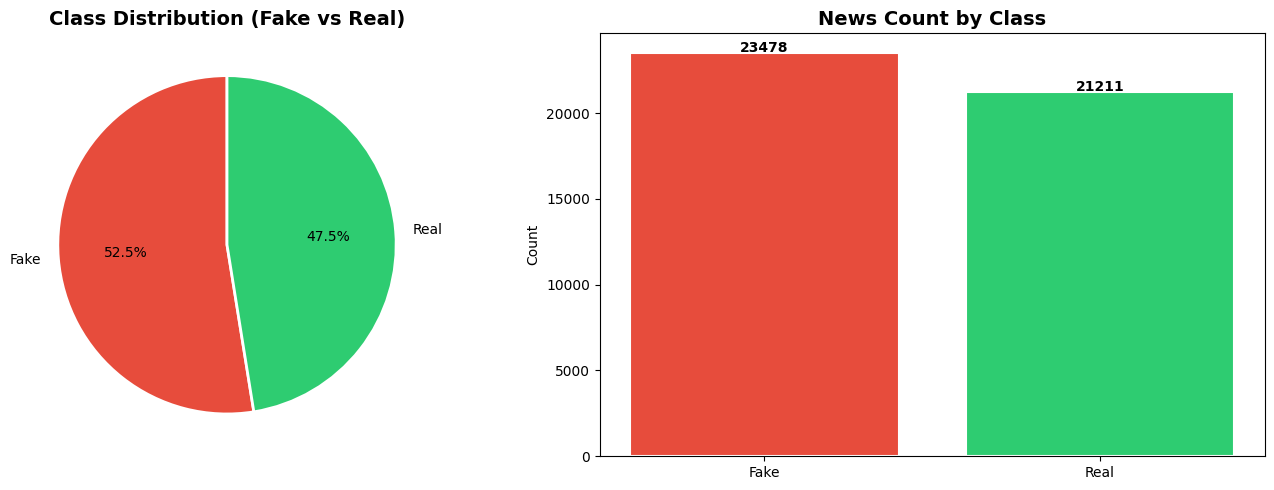

In [10]:
# 1. Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = df['label'].value_counts()
labels = ['Fake', 'Real']
colors = ['#e74c3c', '#2ecc71']

axes[0].pie(label_counts, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Class Distribution (Fake vs Real)', fontsize=14, fontweight='bold')

axes[1].bar(labels, label_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('News Count by Class', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

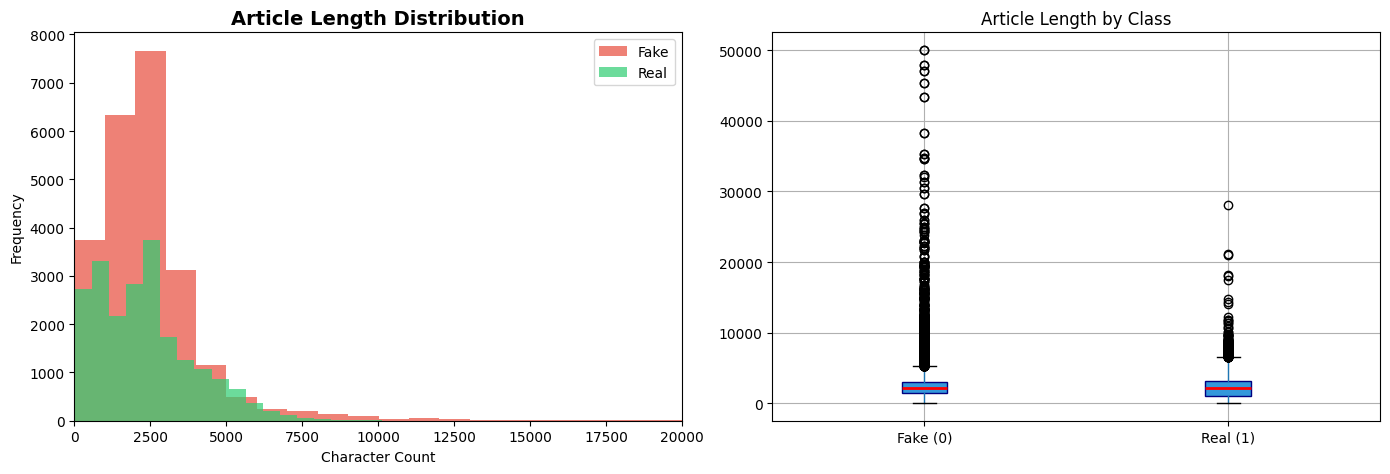

In [11]:
# 2. Article Length Analysis
df['text_length'] = df['content_clean'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fake_len = df[df['label'] == 0]['text_length']
real_len = df[df['label'] == 1]['text_length']

axes[0].hist(fake_len, bins=50, color='#e74c3c', alpha=0.7, label='Fake')
axes[0].hist(real_len, bins=50, color='#2ecc71', alpha=0.7, label='Real')
axes[0].set_title('Article Length Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].set_xlim(0, 20000)

df.boxplot(column='text_length', by='label', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_xticklabels(['Fake (0)', 'Real (1)'])
axes[1].set_title('Article Length by Class')
axes[1].set_xlabel('')
plt.suptitle('')

plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

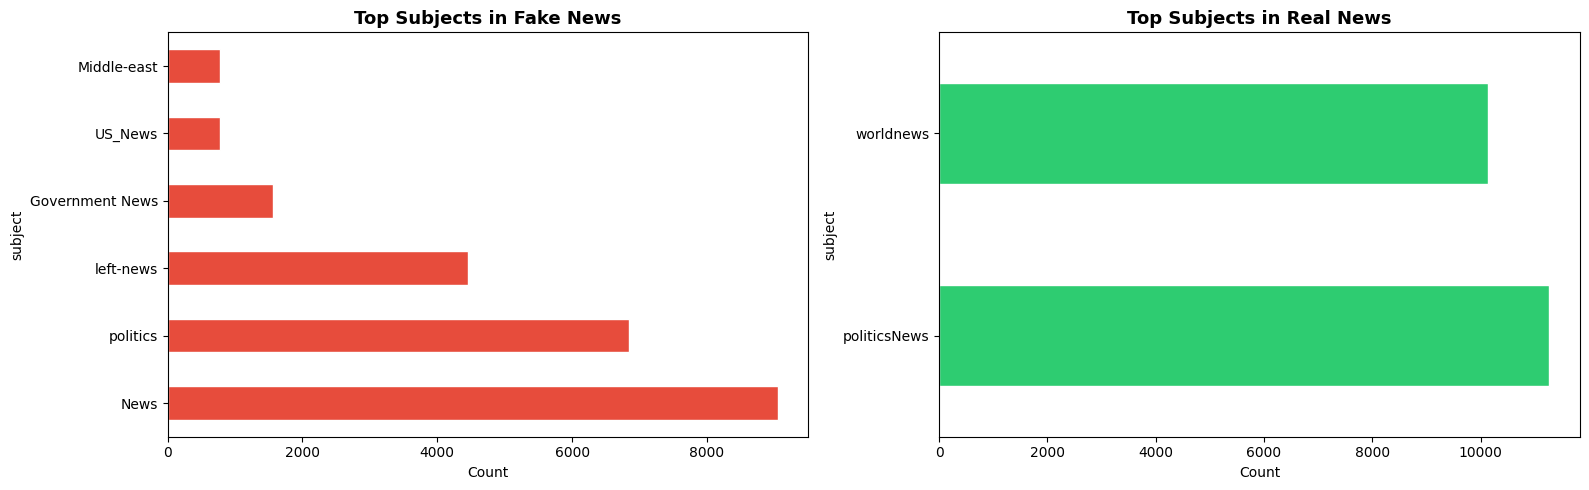

In [12]:
# 3. Subject/Category Distribution
fake_subj = pd.read_csv('Fake.csv')['subject'].value_counts().head(8)
true_subj = pd.read_excel('True.xlsx')['subject'].value_counts().head(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fake_subj.plot(kind='barh', ax=axes[0], color='#e74c3c', edgecolor='white')
axes[0].set_title('Top Subjects in Fake News', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Count')

true_subj.plot(kind='barh', ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Top Subjects in Real News', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('subject_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 6: Feature Extraction — TF-IDF

In [13]:
X = df['content_clean']
y = df['label']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),   # Unigrams + Bigrams
    stop_words='english',
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'\nTF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test) : {X_test_tfidf.shape}')

Training samples : 35751
Testing samples  : 8938

TF-IDF matrix shape (train): (35751, 50000)
TF-IDF matrix shape (test) : (8938, 50000)


## Step 7: Model Training & Evaluation

In [14]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train, predict and return metrics for a model."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)
    print(f'\n{'='*45}')
    print(f'  {name}')
    print(f'{'='*45}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    return {'Model': name, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1-Score': f1, 'y_pred': y_pred, 'object': model}

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=20, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Linear SVM'         : LinearSVC(C=1.0, max_iter=2000)
}

results = []
for name, model in models.items():
    res = evaluate_model(name, model, X_train_tfidf, X_test_tfidf, y_train, y_test)
    results.append(res)


  Logistic Regression
  Accuracy  : 0.9925
  Precision : 0.9904
  Recall    : 0.9939
  F1-Score  : 0.9921

  Naive Bayes
  Accuracy  : 0.9623
  Precision : 0.9595
  Recall    : 0.9611
  F1-Score  : 0.9603

  Decision Tree
  Accuracy  : 0.9945
  Precision : 0.9948
  Recall    : 0.9936
  F1-Score  : 0.9942

  Random Forest
  Accuracy  : 0.9950
  Precision : 0.9936
  Recall    : 0.9958
  F1-Score  : 0.9947

  Linear SVM
  Accuracy  : 0.9977
  Precision : 0.9972
  Recall    : 0.9979
  F1-Score  : 0.9975


## Step 8: Model Comparison

In [15]:
# Summary Table
metrics_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['y_pred', 'object']} for r in results])
metrics_df = metrics_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('\n📊 Model Comparison Summary:')
print(metrics_df.to_string(index=False))


📊 Model Comparison Summary:
              Model  Accuracy  Precision   Recall  F1-Score
         Linear SVM  0.997650   0.997173 0.997878  0.997526
      Random Forest  0.994965   0.993649 0.995757  0.994702
      Decision Tree  0.994518   0.994808 0.993635  0.994221
Logistic Regression  0.992504   0.990369 0.993871  0.992117
        Naive Bayes  0.962296   0.959520 0.961103  0.960311


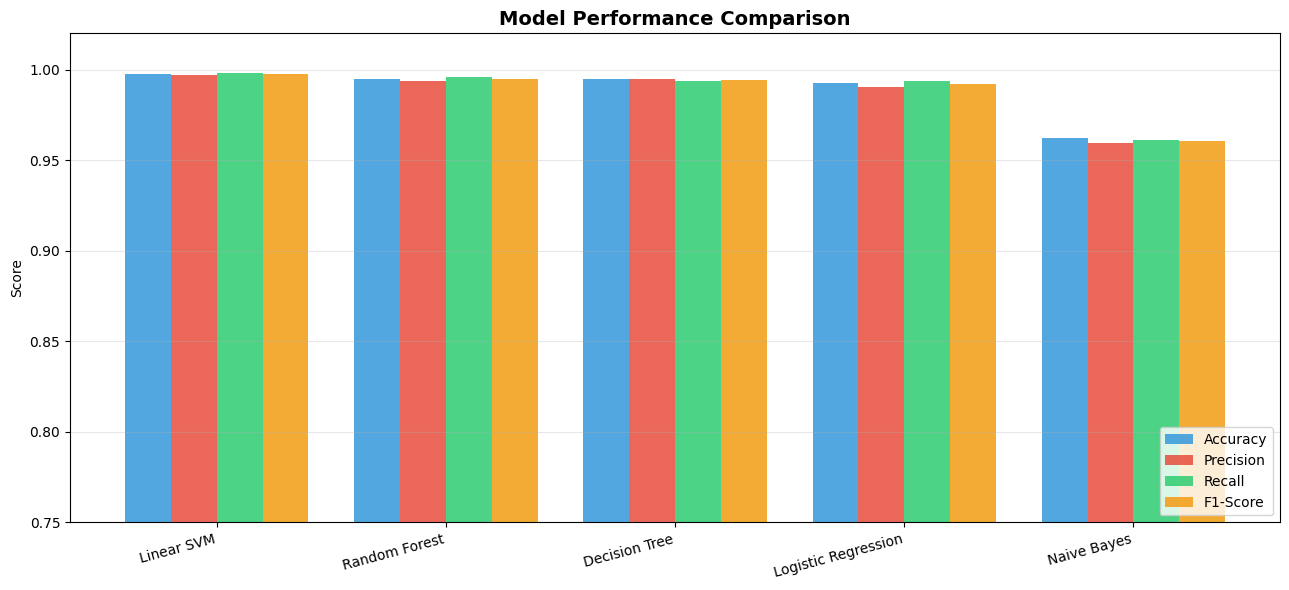

In [16]:
# Comparison Bar Chart
fig, ax = plt.subplots(figsize=(13, 6))
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_df))
width = 0.2
palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, metrics_df[metric], width, label=metric, color=palette[i], alpha=0.85)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_df['Model'], rotation=15, ha='right')
ax.set_ylim(0.75, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 9: Best Model — Confusion Matrix & Classification Report

In [17]:
# Best model = highest F1
best = max(results, key=lambda r: r['F1-Score'])
best_name   = best['Model']
best_model  = best['object']
best_y_pred = best['y_pred']

print(f'🏆 Best Model: {best_name}')
print(f'   F1-Score : {best["F1-Score"]:.4f}')
print(f'   Accuracy : {best["Accuracy"]:.4f}')

print('\n📋 Classification Report:')
print(classification_report(y_test, best_y_pred, target_names=['Fake', 'Real']))

🏆 Best Model: Linear SVM
   F1-Score : 0.9975
   Accuracy : 0.9977

📋 Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4696
        Real       1.00      1.00      1.00      4242

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



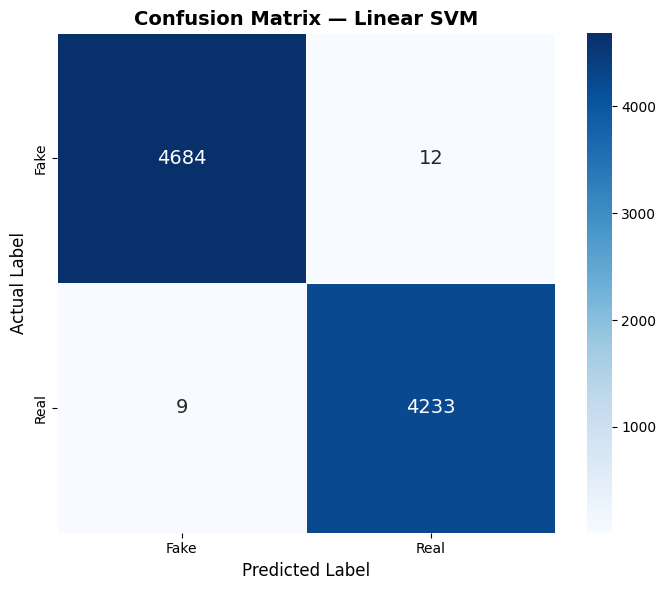

In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'],
            linewidths=0.5, annot_kws={'size': 14})
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 10: Save Model & Vectorizer

In [19]:
# Save the best model
with open('fake_news_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save the TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print(f'✅ Model saved  : fake_news_model.pkl  ({best_name})')
print('✅ Vectorizer saved: tfidf_vectorizer.pkl')

✅ Model saved  : fake_news_model.pkl  (Linear SVM)
✅ Vectorizer saved: tfidf_vectorizer.pkl


## Step 11: Live Prediction Demo

In [20]:
def predict_news(text, model, vectorizer):
    """Predict if a news article is Fake or Real."""
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    label = '✅ REAL NEWS' if pred == 1 else '🚨 FAKE NEWS'
    return label

# Load saved model
with open('fake_news_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('tfidf_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

# Test samples
test_articles = [
    "Scientists discover a new vaccine that cures all known diseases overnight with 100% success rate.",
    "The Federal Reserve raised interest rates by 25 basis points to combat rising inflation, officials confirmed Wednesday.",
    "Obama confirms he is a lizard person and will return to lead Illuminati in 2024!",
    "NASA's James Webb Telescope captures the deepest infrared image of the universe ever taken."
]

print('=== Live Prediction Demo ===\n')
for i, article in enumerate(test_articles, 1):
    result = predict_news(article, loaded_model, loaded_tfidf)
    print(f'Article {i}: {article[:80]}...')
    print(f'Prediction: {result}\n')

=== Live Prediction Demo ===

Article 1: Scientists discover a new vaccine that cures all known diseases overnight with 1...
Prediction: 🚨 FAKE NEWS

Article 2: The Federal Reserve raised interest rates by 25 basis points to combat rising in...
Prediction: 🚨 FAKE NEWS

Article 3: Obama confirms he is a lizard person and will return to lead Illuminati in 2024!...
Prediction: 🚨 FAKE NEWS

Article 4: NASA's James Webb Telescope captures the deepest infrared image of the universe ...
Prediction: 🚨 FAKE NEWS



## Summary

| Step | Description |
|------|-------------|
| 1 | Loaded Fake (23,481) + Real (21,417) news articles |
| 2 | Merged, cleaned and preprocessed text using NLP |
| 3 | Visualized class distribution, text length, subjects |
| 4 | Extracted features using TF-IDF (50K features, bigrams) |
| 5 | Trained 5 models: LR, NB, DT, RF, SVM |
| 6 | Evaluated using Accuracy, Precision, Recall, F1-Score |
| 7 | Saved best model and vectorizer as .pkl files |
| 8 | Demonstrated live prediction on new articles |

---
*Project: Fake News Detection System | Tech Stack: Python, Scikit-learn, NLTK, TF-IDF*